# SnapKV LongBench on Qwen3.5-0.8B

Minimal [LongBench](https://arxiv.org/abs/2308.14508) reproduction using this repo's **SnapKV** port ([`modify_qwen.py`](modify_qwen.py)), adapted from SnapKV's [`pred_snap.py`](https://github.com/FasterDecoding/SnapKV/blob/main/experiments/LongBench/pred_snap.py).

**Runs:** Full-KV baseline vs SnapKV-compressed at `max_capacity_prompt` ∈ {1024, 2048, 4096} (`window_size=32`, `kernel_size=7`, `maxpool`).

**Hardware:** GPU recommended (A100-class for long contexts). Upload or clone this repo so `modify_qwen.py` is importable.

**Smoke test:** set `SMOKE_TEST = True` (2 samples, `qasper` only) before a full run.

Citations: LongBench (Bai et al., 2023); SnapKV (Li et al., [arXiv:2404.14469](https://arxiv.org/abs/2404.14469)).

In [ ]:
# Optional Colab drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/abhipa871/SnapKVCacheLLMPaperImplementation.git

Cloning into 'SnapKVCacheLLMPaperImplementation'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 41 (delta 10), reused 37 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 588.57 KiB | 21.80 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [ ]:
!pip install -q -U transformers datasets==3.6.0 accelerate rouge jieba fuzzywuzzy python-Levenshtein tqdm pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 164.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 151.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 154.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 118.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires p

In [ ]:
%cd /content/SnapKVCacheLLMPaperImplementation

/content/SnapKVCacheLLMPaperImplementation


In [ ]:
import copy
import gc
import json
import os
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoTokenizer

REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modify_qwen import SnapKVQwen3_5ForCausalLM
from longbench_metrics import scorer

CONFIG_DIR = REPO_ROOT / 'longbench_config'
dataset2prompt = json.loads((CONFIG_DIR / 'dataset2prompt.json').read_text(encoding='utf-8'))
dataset2maxlen = json.loads((CONFIG_DIR / 'dataset2maxlen.json').read_text(encoding='utf-8'))

[ERROR] `prefill_final_chunk` is part of SnapKVQwen3_5TextModel.forward's signature, but not documented. Make sure to add it to the docstring of the function in /content/SnapKVCacheLLMPaperImplementation/modify_qwen.py.
[ERROR] `hf_chunked_prefill` is part of SnapKVQwen3_5TextModel.forward's signature, but not documented. Make sure to add it to the docstring of the function in /content/SnapKVCacheLLMPaperImplementation/modify_qwen.py.


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


In [ ]:
# --- Configuration ---
MODEL_ID = 'Qwen/Qwen3.5-0.8B'

ALL_DATASETS = [
    'narrativeqa', 'qasper', 'multifieldqa_en', 'hotpotqa', '2wikimqa', 'musique',
    'gov_report', 'qmsum', 'multi_news', 'trec', 'triviaqa', 'samsum',
    'passage_count', 'passage_retrieval_en', 'lcc', 'repobench-p',
]
DEFAULT_DATASETS = ['qasper', 'hotpotqa', 'multifieldqa_en']

# Smoke test: 2 samples on qasper only. Set False for DEFAULT_DATASETS or all tasks.
SMOKE_TEST = False
RUN_ALL_DATASETS = False
SAMPLE_LIMIT = None  # e.g. 5 for quick dev; None = full test split
USE_LONGBENCH_E = False

if SMOKE_TEST:
    DATASETS = ['qasper']
    SAMPLE_LIMIT = 2
elif RUN_ALL_DATASETS:
    DATASETS = ALL_DATASETS
else:
    DATASETS = DEFAULT_DATASETS

base_cfg = AutoConfig.from_pretrained(MODEL_ID, trust_remote_code=True)
text_cfg = getattr(base_cfg, 'text_config', None) or base_cfg
MAX_INPUT_TOKENS = getattr(text_cfg, 'max_position_embeddings', 32768) - 512

BASELINE_BUDGET = dict(
    max_capacity_prompt=MAX_INPUT_TOKENS,
    window_size=32,
    kernel_size=7,
    pooling='maxpool',
)
SNAPKV_SHARED = dict(
    window_size=32,
    kernel_size=7,
    pooling='maxpool',
)
SNAPKV_CAPACITIES = [1024, 2048, 4096]

RUNS = {'qwen35-0.8b-baseline': BASELINE_BUDGET}
for cap in SNAPKV_CAPACITIES:
    run_name = f'qwen35-0.8b-snapkv-c{cap}-w32'
    RUNS[run_name] = dict(max_capacity_prompt=cap, **SNAPKV_SHARED)

NO_CHAT_WRAP = {'trec', 'triviaqa', 'samsum', 'lsht', 'lcc', 'repobench-p'}

print('Datasets:', DATASETS)
print('MAX_INPUT_TOKENS:', MAX_INPUT_TOKENS)
print('SnapKV capacities:', SNAPKV_CAPACITIES)
print('Runs:', list(RUNS.keys()))

config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

Datasets: ['qasper', 'hotpotqa', 'multifieldqa_en']
MAX_INPUT_TOKENS: 261632


In [ ]:
def release_gpu_memory(*objs):
    """Drop references and return cached GPU memory to the allocator."""
    for obj in objs:
        del obj
        torch.cuda.empty_cache()
        gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def seed_everything(seed: int = 42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def patch_snapkv_budget(cfg, **kwargs):
    c = copy.deepcopy(cfg)
    for obj in filter(None, (c, getattr(c, 'text_config', None))):
        for key, value in kwargs.items():
            setattr(obj, key, value)
    return c


def apply_snapkv_budget_to_model(model, budget: dict):
    inner_cfg = model.model.language_model.config
    for layer_idx, layer in enumerate(model.model.language_model.layers):
        if inner_cfg.layer_types[layer_idx] == 'linear_attention':
            continue
        cache = layer.self_attn.snap_kv_cache
        cache.window_size = budget['window_size']
        cache.max_capacity_prompt = budget['max_capacity_prompt']
        cache.kernel_size = budget['kernel_size']
        cache.pooling = budget['pooling']


def load_snapkv_model(budget: dict):
    cfg = patch_snapkv_budget(base_cfg, **budget)
    dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    device_kw = {'device_map': 'cuda:0'} if torch.cuda.is_available() else {'device_map': 'cpu'}
    model = SnapKVQwen3_5ForCausalLM.from_pretrained(
        MODEL_ID,
        config=cfg,
        torch_dtype=dtype,
        trust_remote_code=True,
        attn_implementation='eager',
        **device_kw,
    ).eval()
    apply_snapkv_budget_to_model(model, budget)
    return model


def build_prompt(sample: dict, dataset: str) -> str:
    return dataset2prompt[dataset].format(**sample)


def truncate_middle(tokenizer, prompt: str, max_length: int) -> str:
    tokenized = tokenizer(prompt, truncation=False, return_tensors='pt').input_ids[0]
    if len(tokenized) <= max_length:
        return prompt
    half = int(max_length / 2)
    return tokenizer.decode(tokenized[:half], skip_special_tokens=True) + tokenizer.decode(
        tokenized[-half:], skip_special_tokens=True
    )


def tokenize_prompt(tokenizer, prompt: str, dataset: str):
    if dataset in NO_CHAT_WRAP:
        return tokenizer(prompt, truncation=False, return_tensors='pt')
    if not getattr(tokenizer, 'chat_template', None):
        return tokenizer(prompt, truncation=False, return_tensors='pt')
    text = tokenizer.apply_chat_template(
        [{'role': 'user', 'content': prompt}],
        tokenize=False,
        add_generation_prompt=True,
    )
    return tokenizer(text, truncation=False, return_tensors='pt')

In [ ]:
@torch.inference_mode()
def predict_dataset(model, tokenizer, dataset: str, out_path: Path, max_input_tokens: int):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists():
        out_path.unlink()

    hf_name = f'{dataset}_e' if USE_LONGBENCH_E else dataset
    data = load_dataset('THUDM/LongBench', hf_name, split='test')
    if SAMPLE_LIMIT is not None:
        data = data.select(range(min(SAMPLE_LIMIT, len(data))))

    max_gen = dataset2maxlen[dataset]
    device = model.device

    for sample in tqdm(data, desc=f'predict:{dataset}'):
        prompt = build_prompt(sample, dataset)
        prompt = truncate_middle(tokenizer, prompt, max_input_tokens)
        batch = tokenize_prompt(tokenizer, prompt, dataset)
        batch = {k: v.to(device) for k, v in batch.items()}
        context_length = batch['input_ids'].shape[-1]

        gen_kwargs = dict(
            max_new_tokens=max_gen,
            num_beams=1,
            do_sample=False,
            temperature=1.0,
            min_length=context_length + 1,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
        )
        if dataset == 'samsum':
            gen_kwargs['eos_token_id'] = [
                tokenizer.eos_token_id,
                tokenizer.encode('\n', add_special_tokens=False)[-1],
            ]

        output = model.generate(**batch, **gen_kwargs)[0]
        pred = tokenizer.decode(output[context_length:], skip_special_tokens=True)
        del batch, output

        record = {
            'pred': pred,
            'answers': sample['answers'],
            'all_classes': sample.get('all_classes', None),
            'length': sample.get('length', None),
        }
        with out_path.open('a', encoding='utf-8') as f:
            f.write(json.dumps(record, ensure_ascii=False) + '\n')

    release_gpu_memory(data)


def evaluate_predictions(pred_dir: Path) -> dict:
    scores = {}
    for path in sorted(pred_dir.glob('*.jsonl')):
        dataset = path.stem
        predictions, answers, all_classes = [], [], None
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                row = json.loads(line)
                predictions.append(row['pred'])
                answers.append(row['answers'])
                all_classes = row['all_classes']
        scores[dataset] = scorer(dataset, predictions, answers, all_classes)
    return scores


def run_longbench_suite(run_name: str, budget: dict):
    seed_everything(42)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    tokenizer.padding_side = 'left'
    model = load_snapkv_model(budget)

    pred_root = REPO_ROOT / 'pred' / run_name
    for dataset in DATASETS:
        predict_dataset(
            model,
            tokenizer,
            dataset,
            pred_root / f'{dataset}.jsonl',
            MAX_INPUT_TOKENS,
        )

    scores = evaluate_predictions(pred_root)
    result_dir = REPO_ROOT / 'results' / run_name
    result_dir.mkdir(parents=True, exist_ok=True)
    with (result_dir / 'result.json').open('w', encoding='utf-8') as f:
        json.dump(scores, f, ensure_ascii=False, indent=2)
    print(json.dumps(scores, indent=2))
    return scores

In [ ]:
baseline_scores = run_longbench_suite('qwen35-0.8b-baseline', BASELINE_BUDGET)
release_gpu_memory()
print('Baseline run finished; GPU cache cleared before SnapKV run.')

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

...

Generating test split: 0 examples [00:00, ? examples/s]

predict:hotpotqa:   0%|          | 0/200 [00:00<?, ?it/s]

Generating test split: 0 examples [00:00, ? examples/s]

predict:multifieldqa_en:   0%|          | 0/150 [00:00<?, ?it/s]

{
  "hotpotqa": 39.51,
  "multifieldqa_en": 49.45,
  "qasper": 30.49
}
Baseline run finished; GPU cache cleared before SnapKV run.


In [ ]:
snapkv_scores_by_cap = {}
for cap in SNAPKV_CAPACITIES:
    run_name = f'qwen35-0.8b-snapkv-c{cap}-w32'
    print(f'--- SnapKV max_capacity_prompt={cap} ---')
    snapkv_scores_by_cap[cap] = run_longbench_suite(run_name, RUNS[run_name])
    release_gpu_memory()
    print(f'SnapKV c{cap} finished; GPU cache cleared.')

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

predict:qasper:   0%|          | 0/200 [00:00<?, ?it/s]

predict:hotpotqa:   0%|          | 0/200 [00:00<?, ?it/s]

predict:multifieldqa_en:   0%|          | 0/150 [00:00<?, ?it/s]

{
  "hotpotqa": 39.47,
  "multifieldqa_en": 48.25,
  "qasper": 29.9
}
SnapKV run finished; GPU cache cleared.


,dataset,baseline,snapkv,delta
0,qasper,30.49,29.90,-0.59
1,hotpotqa,39.51,39.47,-0.04
2,multifieldqa_en,49.45,48.25,-1.20


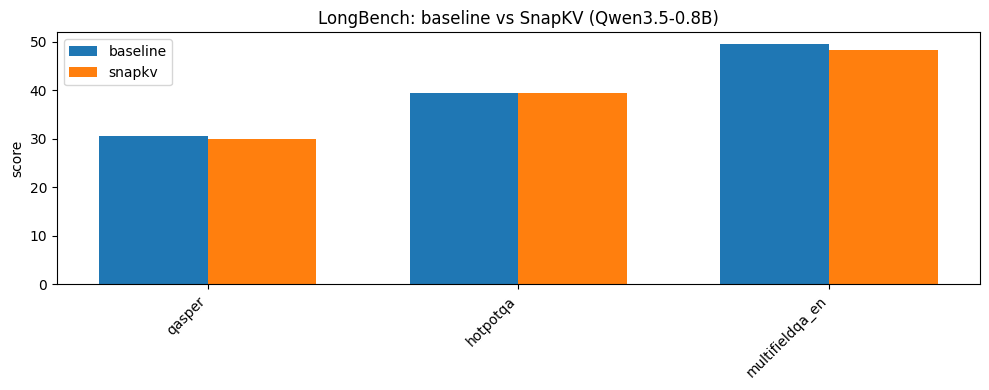

In [ ]:
rows = []
for dataset in DATASETS:
    row = {'dataset': dataset, 'baseline': baseline_scores.get(dataset)}
    for cap in SNAPKV_CAPACITIES:
        score = snapkv_scores_by_cap[cap].get(dataset)
        row[f'snapkv_c{cap}'] = score
        row[f'delta_c{cap}'] = (score or 0) - (baseline_scores.get(dataset) or 0)
    rows.append(row)

comparison = pd.DataFrame(rows)
comparison_path = REPO_ROOT / 'results' / 'comparison.csv'
comparison_path.parent.mkdir(parents=True, exist_ok=True)
comparison.to_csv(comparison_path, index=False)
display(comparison)

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(comparison))
    n_bars = 1 + len(SNAPKV_CAPACITIES)
    width = 0.8 / n_bars
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * width

    ax.bar(x + offsets[0], comparison['baseline'], width, label='baseline')
    for i, cap in enumerate(SNAPKV_CAPACITIES, start=1):
        ax.bar(x + offsets[i], comparison[f'snapkv_c{cap}'], width, label=f'snapkv c{cap}')

    ax.set_xticks(x, comparison['dataset'], rotation=45, ha='right')
    ax.set_ylabel('score')
    ax.set_title('LongBench: baseline vs SnapKV capacities (Qwen3.5-0.8B)')
    ax.legend()
    fig.tight_layout()
    plt.show()
except Exception as exc:
    print('Plot skipped:', exc)